In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
export_hwannier("wannier", spin=Val('n'));
export_momentum("wannier", spin=Val('n'));
export_heph("wannier", spin=Val('n'));

In [4]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt")
Pwannier = pwannier("wannier");
Heph, celleph_map = hephwannier("wannier"), np.loadtxt("wannier.mapeph.txt");

In [5]:
dirac_point = wannier_bands(Hwannier, cell_map, [2/3, -1/3, 0])[1][5]
lattice_vectors = loadlattice("graphene.out");

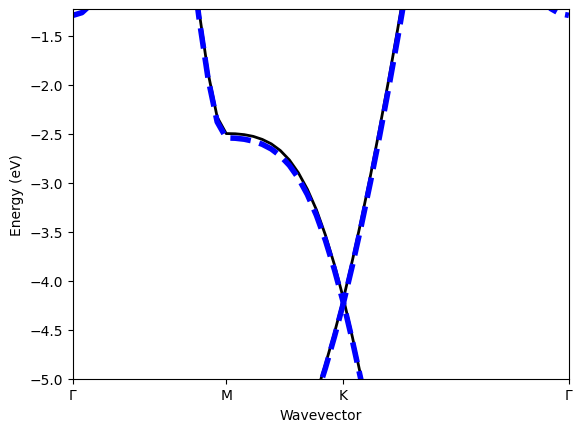

(-5.0, -1.2259635003760794)

In [6]:
plot_bands("graphene.bands.eigenvals", to_greek=true)
plot_bands(Hwannier, cell_map, linestyle="dashed", linewidth=4, color="blue")
ylim(-5, dirac_point+3)

In [20]:
sigma1 = interbandsigma(lattice_vectors, Hwannier, cell_map, Pwannier, dirac_point+0.5, mesh=64,
    num_blocks=500, degeneracy=2, histogram_width=100, energy_range=3)


Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100
Block: 1

3×3×300 Array{ComplexF64, 3}:
[:, :, 1] =
 NaN+NaN*im  NaN+NaN*im  NaN+NaN*im
 NaN+NaN*im  NaN+NaN*im  NaN+NaN*im
 NaN+NaN*im  NaN+NaN*im  NaN+NaN*im

[:, :, 2] =
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im

[:, :, 3] =
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im

...

[:, :, 298] =
     1.87072+0.0im          …  3.78646e-10+1.66643e-10im
   0.0306561-1.86036e-10im     8.37274e-10-8.61634e-11im
 3.78646e-10-1.66643e-10im     8.06419e-18+0.0im

[:, :, 299] =
     1.76488+0.0im          …  4.21889e-10-8.79807e-11im
   0.0129466+1.34558e-10im     7.75482e-10+6.21103e-11im
 4.21889e-10+8.79807e-11im     8.40474e-18+0.0im

[:, :, 300] =
     1.86393+0.0im          …  4.37246e-10-4.22292e-11im
    0.067913-3.64078e-10im     8.14232e-10+4.23968e-11im
 4.37246e-10+4.22292e-11im     8.70975e-18+0.0im

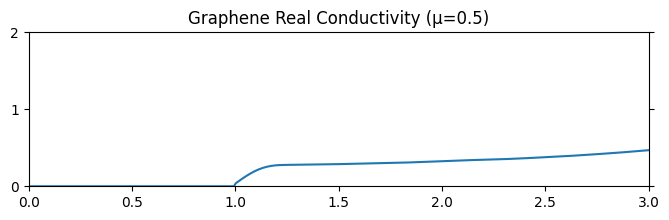

In [147]:
figure(figsize=(8, 2))
plot(range(0, 3, length=300), np.loadtxt("graphene_sigma_0.5.txt"))
ylim(0, 2)
xlim(0, 3)
yticks([0, 1, 2])
title("Graphene Real Conductivity (μ=0.5)")
tick_params(right=true)

In [87]:
graphene_sigma_ω(0.1)

-0.012101463656003914 - 1.0083610306034539e-5im

In [121]:
function graphene_sigma_ω(ω::Real)
    # At 0.5 eV doping
    im_sigma = real(kramers_kronig_reverse(ω, collect(range(0, 3, length=300)),
        np.loadtxt("graphene_sigma_0.5.txt"))*4)
    end

graphene_sigma_ω (generic function with 1 method)

In [136]:
N=1000
p = zeros(N, N)
omega_range = range(0.01, 1, length=N)
q_range = range(0, 0.04, length=N)
for (j, ω) in enumerate(omega_range)
    sigma_I = graphene_sigma_ω(ω)
    for (i, q) in enumerate(q_range)
        p[i, j] = e²ϵ/2*q - ω/(0.6454/4/ω + sigma_I/4)
    end
end


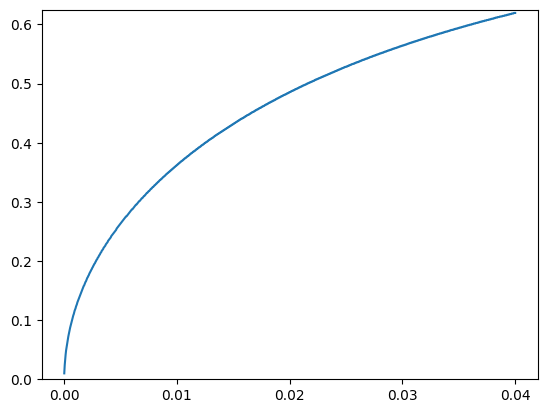

(0.0, 0.625)

In [164]:
plot(q_range, smooth(omega_range[[argmin(x) for x in eachrow(log.(abs.(p)))]], win_len=1))
xticks([0, 0.01, 0.02, 0.03, 0.04])
ylim(0, 0.625)

In [ ]:
### np.savetxt("graphene_sigma_0.5.txt", [zeros(100)..., smooth((real.(sigma1[1, 1, :]+sigma1[2, 2, :])[101:end])/2/4, win_len=50)...])

In [51]:
drude_conductivity(lattice_vectors, Hwannier, cell_map, Pwannier, mesh=32, num_blocks=100, histogram_width=20, degeneracy=2)

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100


([-100.0, -99.94998749687421, -99.89997499374844, -99.84996249062266, -99.79994998749687, -99.74993748437109, -99.69992498124532, -99.64991247811953, -99.59989997499375, -99.54988747186796  …  99.54988747186796, 99.59989997499375, 99.64991247811953, 99.69992498124532, 99.74993748437109, 99.79994998749687, 99.84996249062266, 99.89997499374844, 99.94998749687421, 100.0], [0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0]

[0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0]

[0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0])

In [75]:
np.savetxt("graphene_drude_sigma.txt", smooth(d[:, 2, 2] + d[:, 1, 1], win_len=10)/2)

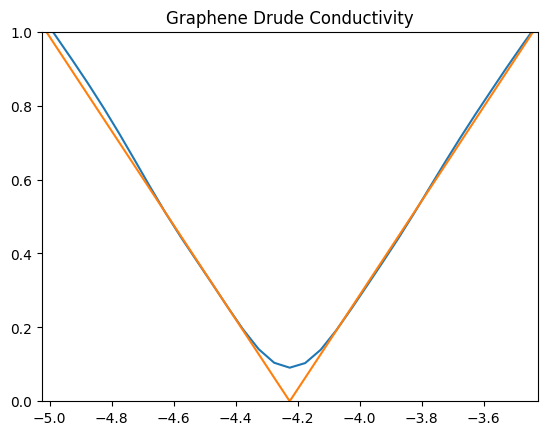

PyObject Text(0.5, 1.0, 'Graphene Drude Conductivity')

In [75]:
e = range(-100, 100, length=200*20)
plot(e, np.loadtxt("graphene_drude_sigma.txt"))
plot(e, abs.(e .- dirac_point)*4/pi)
xlim(dirac_point-0.8, dirac_point+0.8)
ylim(0, 1)
title("Graphene Drude Conductivity")

In [86]:
np.loadtxt("graphene_drude_sigma.txt")[argmin(abs.(e .- dirac_point .- 0.5))]

0.6454314891481261

In [146]:
.04/(.5/6)

0.48000000000000004

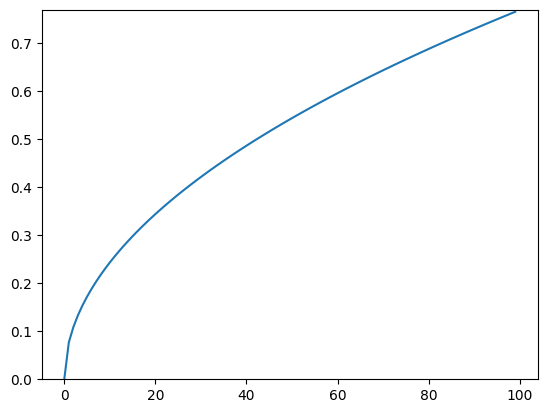

(0.0, 0.77)

In [144]:
plot(sqrt.(range(0, 0.04, length=100)*e²ϵ*0.6454/8))
ylim(0, 0.77)

In [138]:
np.savetxt("graphene_sigma_0.3.txt", real(sigma))

In [194]:
sigma = np.loadtxt("graphene_sigma_0.3.txt");
drude_sigma = np.loadtxt("graphene_drude_sigma_0.3.txt");

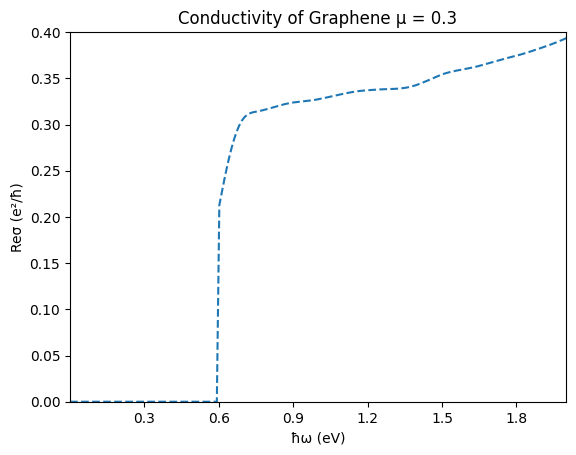

(PyObject[PyObject <matplotlib.axis.XTick object at 0x7f23eaf803d0>, PyObject <matplotlib.axis.XTick object at 0x7f23eaf803a0>, PyObject <matplotlib.axis.XTick object at 0x7f23ead28eb0>, PyObject <matplotlib.axis.XTick object at 0x7f23eafa60d0>, PyObject <matplotlib.axis.XTick object at 0x7f23eafa64f0>, PyObject <matplotlib.axis.XTick object at 0x7f23eafa6940>], PyObject[PyObject Text(0.3, 0, '0.3'), PyObject Text(0.6, 0, '0.6'), PyObject Text(0.9, 0, '0.9'), PyObject Text(1.2, 0, '1.2'), PyObject Text(1.5, 0, '1.5'), PyObject Text(1.8, 0, '1.8')])

In [155]:
plot(range(0, 3, length=300), [sigma[1:60]..., smooth(sigma[61:end], win_len=30)...] ./4, linestyle="dashed")
xlim(0, 2)
ylim(0, 0.4)
ylabel("Reσ (e²/ħ)")
xlabel("ħω (eV)")
title("Conductivity of Graphene μ = 0.3")
xticks([0.3, 0.6, 0.9, 1.2, 1.5, 1.8])

In [186]:
force_matrix, cellph_map = phonon_force_matrix("graphene");
phonon_bands = phonon_dispersion(force_matrix, cellph_map, return_negative=true);

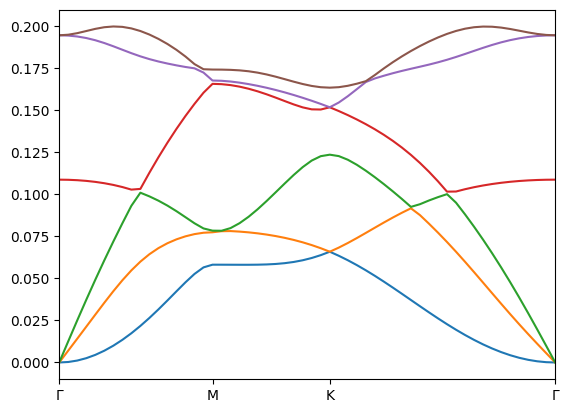

(0.0, 55.0)

In [187]:
plot(phonon_bands)
label_plots()
#ylim(0, 0.1)

In [95]:
function ImΠGraphene(Hwannier::Array{Float64, 3}, cell_map::Array{Float64, 2}, lattice_vectors::Vector{<:Vector{<:Real}}, q::Vector{<:Real}, μ::Real, dim::Val{D}=Val(2); 
    degeneracy::Integer=1, mesh::Integer=100, num_blocks::Integer, 
        subsampling::Integer =10, histogram_width::Integer=100, monte_carlo::Bool = false, verbose::Bool=true, normalized::Bool=true) where D

    verbose && println(q); flush(stdout)
    Polarization_Array=zeros(histogram_width*100)
    V = 
        if D == 2 
            unit_cell_area(lattice_vectors) 
        elseif D ==3
            unit_cell_volume(lattice_vectors)
        end

    qnormalized = normalized ? q : normalize_kvector(lattice_vectors, q)

    for _ in 1:num_blocks
        kpoints =  (vcat(rand(D, mesh^D), zeros(3-D, mesh^D)) .- [1/2, 1/2, 0]) ./ subsampling .+ [2/3, -1/3, 0]

        kplusqpoints = reshape(repeat(qnormalized, mesh^D), (3, mesh^D)) + kpoints

        Eks, Uks = wannier_bands(Hwannier, cell_map, kpoints)
        Ekqs, Ukqs = wannier_bands(Hwannier, cell_map, kplusqpoints)
        
        numbands = size(Eks)[2]
        overlaps = np.einsum("lji, ljk -> lik", np.conj(Uks), Ukqs) # l indexes the k point, i and k index the band indices
        overlaps = overlaps .* np.conj(overlaps) # lij component is |<i, k_l| j, k_l+q>|^2

        Ekqs_reshaped = np.repeat(np.reshape(Ekqs, (mesh^D, 1, numbands)), numbands, axis=1)
        Eks_reshaped = np.repeat(np.reshape(Eks, (mesh^D, numbands, 1)), numbands, axis=2)
        omegas = Ekqs_reshaped - Eks_reshaped # lij component is E(k_l + q)_j - E(k_l)_i

        f2 = np.heaviside(μ .- Ekqs_reshaped, 0.5)
        f1 = np.heaviside(μ .- Eks_reshaped, 0.5)

        summand = (f2 - f1) .* overlaps

        Polarization_Array += first(np.histogram(omegas, bins=round(Int, histogram_width*100), 
                weights=summand, range=(0, 100)))*π/V*1/(subsampling)^2*(1/mesh)^D*histogram_width*degeneracy*(1/num_blocks)
    end
    return Polarization_Array
end


ImΠGraphene (generic function with 2 methods)

In [255]:
dirac_point

-4.225963500376079

In [98]:
.5/6/2

0.041666666666666664

In [115]:
μ = dirac_point + 0.5
impolarizations = []
N=100
for i in 1:N
    println(i); flush(stdout)
    push!(impolarizations, real.(ImΠGraphene(Hwannier, cell_map, lattice_vectors, [i/N*(μ-dirac_point)/12, 0, 0], μ,
                monte_carlo=true, normalized=false, histogram_width=10000, degeneracy=4, mesh=64, num_blocks=15)))
end

1
[0.0004166666666666667, 0.0, 0.0]
2
[0.0008333333333333334, 0.0, 0.0]
3
[0.00125, 0.0, 0.0]
4
[0.0016666666666666668, 0.0, 0.0]
5
[0.0020833333333333333, 0.0, 0.0]
6
[0.0025, 0.0, 0.0]
7
[0.002916666666666667, 0.0, 0.0]
8
[0.0033333333333333335, 0.0, 0.0]
9
[0.00375, 0.0, 0.0]
10
[0.004166666666666667, 0.0, 0.0]
11
[0.004583333333333333, 0.0, 0.0]
12
[0.005, 0.0, 0.0]
13
[0.005416666666666667, 0.0, 0.0]
14
[0.005833333333333334, 0.0, 0.0]
15
[0.0062499999999999995, 0.0, 0.0]
16
[0.006666666666666667, 0.0, 0.0]
17
[0.007083333333333334, 0.0, 0.0]
18
[0.0075, 0.0, 0.0]
19
[0.007916666666666667, 0.0, 0.0]
20
[0.008333333333333333, 0.0, 0.0]
21
[0.008749999999999999, 0.0, 0.0]
22
[0.009166666666666667, 0.0, 0.0]
23
[0.009583333333333334, 0.0, 0.0]
24
[0.01, 0.0, 0.0]
25
[0.010416666666666666, 0.0, 0.0]
26
[0.010833333333333334, 0.0, 0.0]
27
[0.011250000000000001, 0.0, 0.0]
28
[0.011666666666666667, 0.0, 0.0]
29
[0.012083333333333333, 0.0, 0.0]
30
[0.012499999999999999, 0.0, 0.0]
31
[0.01

In [111]:
(0:(μ-dirac_point)/30:1.5(μ-dirac_point))[40]

0.65

In [121]:
omegarange = 0:(μ-dirac_point)/30:1.5(μ-dirac_point)
epsilons = zeros(ComplexF64, (length(impolarizations), length(omegarange)))
for i in 1:N
    println(i); flush(stdout)
    impol = smooth(impolarizations[i], win_len=30)
    for (j, ω) in enumerate(omegarange)
        epsilons[i, j] = ϵ([i/N*(μ-dirac_point)/12, 0, 0], lattice_vectors, ω, collect(range(0, 100, length=1000000)), 
            impol, normalized=false, δ=0.03)
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


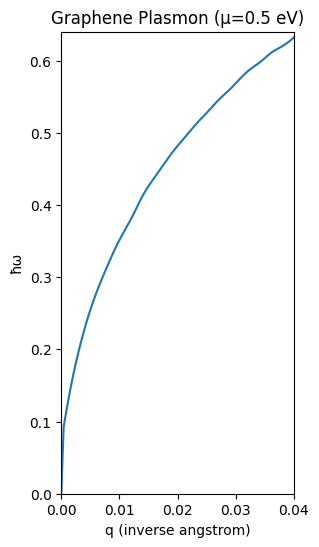

PyObject Text(24.0, 0.5, 'ħω')

In [161]:
figure(figsize=(3, 6))
plot(range(0, 1/24, length=101), np.loadtxt("graphene_plasmon_0.5eV.txt"))
ylim(0, 0.64)
xlim(-0, 0.04)
title("Graphene Plasmon (μ=0.5 eV)")
xlabel("q (inverse angstrom)")
ylabel("ħω")

In [157]:
np.savetxt("graphene_plasmon_0.5eV.txt",
    [0, smooth((0:1/30:1.5)[[argmin(x) for x in eachrow(log.(abs.(epsilons)))]], win_len=14)/2...])

In [176]:
subsampling = returnfermikpoint(Hwannier, cell_map, -4.226+0.5, Val(2), mesh=30, num_blocks=10000, histogram_width=10)

(Real[0.29810512219337815 0.33829075081168525 … 0.2992449207360919 0.33788797445903507; 0.36495245988471847 0.36537437877151113 … 0.33967423769935 0.29792542260017907; 0.0 0.0 … 0.0 0.0], 0.002966111111111111)

In [167]:
JJDFTX.dosatmu(Hwannier, cell_map, -4.226+0.5, mesh=20, num_blocks=60, histogram_width=10)

0.029166666666666667

In [177]:
subsampling[1]

3×26695 Matrix{Real}:
 0.298105  0.338291  0.355089  0.333922  …  0.33078   0.299245  0.337888
 0.364952  0.365374  0.296012  0.303085     0.368411  0.339674  0.297925
 0.0       0.0       0.0       0.0          0.0       0.0       0.0

In [71]:
(.0263-0.02456)/0.02456*100

7.084690553745937

In [67]:
5.245957679219971/pi*1/5.83*1/5.83*0.5

0.024564492993263853

In [66]:
3/2*1.44*2.7

5.832000000000001

In [188]:
tau =  τ(Hwannier, cell_map, Pwannier, force_matrix, cellph_map,
    Heph, celleph_map, collect(0.01:0.01:1), -4.226+0.5, Val(2);supplysampling=subsampling, supplydos = 0.029, histogram_width=10, mesh=64, num_blocks=1, fracroom=1)

DOS at Fermi Energy is: 0.029
Sampling from 26695kpoints
Block: 1


100-element Vector{Float64}:
 1335.557057497394
 1087.2493275671056
  886.3314133465452
  723.2137918009327
  590.4186742876018
  482.11480089291814
  393.73230543236593
  321.6531114608206
  262.9713998056454
  215.31644417868307
  176.72740188372543
  145.56783422587392
  120.46773590099961
    ⋮
    6.742370013986708
    6.712206242773853
    6.682860889157707
    6.65430109042623
    6.626495720053368
    6.599415274536997
    6.573031768974173
    6.547318640595759
    6.5222506595627205
    6.4978038463932
    6.473955395452882
    6.450683603995487

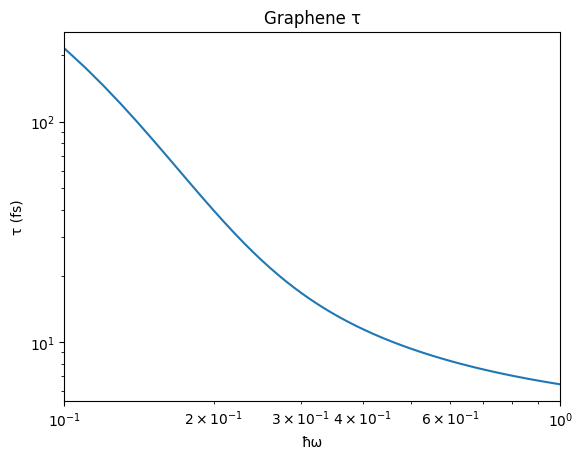

PyObject Text(24.000000000000007, 0.5, 'τ (fs)')

In [199]:
loglog(collect(0.1:0.01:1), np.loadtxt("graphene_tau_0.5.txt"))
xlim(0.1, 1)
title("Graphene τ")
xlabel("ħω")
ylabel("τ (fs)")

In [191]:
collect(0.01:0.01:1)[11]

0.11

In [61]:
tau =  tauinverse(Hwannier, cellmap, Pwannier, force_matrix, cell_map,
    heph, cellmapeph, collect(0.01:0.01:1), dirac_point+0.5, 7;supplysampling=([x..., x1...], y+y1), supplydos = 0.029, histogram_width=100, mesh=20, mesh2=1000, fracroom=1)

DOS at Fermi Energy is: 0.029Sampling from 383kpoints


100-element Vector{Float64}:
 7.350988127031073e11
 7.973153274258724e11
 8.718976077982253e11
 9.615201716178081e11
 1.0693866533431884e12
 1.1992689854291543e12
 1.3555120812681917e12
 1.5429868751147776e12
 1.7669738449431445e12
 2.0329615332678132e12
 2.346351673975141e12
 2.7120754365723433e12
 3.1341436667796196e12
 ⋮
 2.8707997503063395e13
 2.8784865037754965e13
 2.8860043176082184e13
 2.8933587007056367e13
 2.900554925026869e13
 2.907598038192419e13
 2.914492875291385e13
 2.9212440699508227e13
 2.9278560647203953e13
 2.934333120821225e13
 2.9406793273038703e13
 2.9468986096568617e13

In [197]:
np.savetxt("graphene_tau_0.5.txt", tau[10:end])

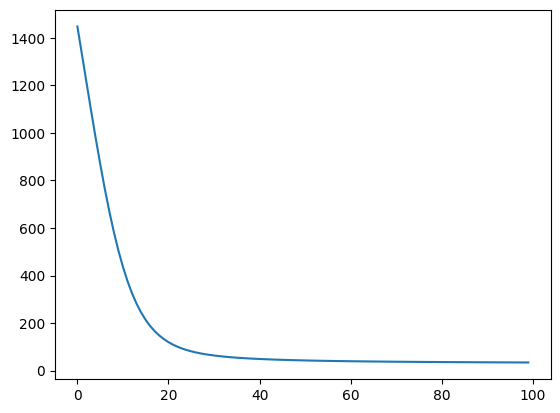

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7faef46c4190>

In [51]:
plot( 1e15 ./ tau)

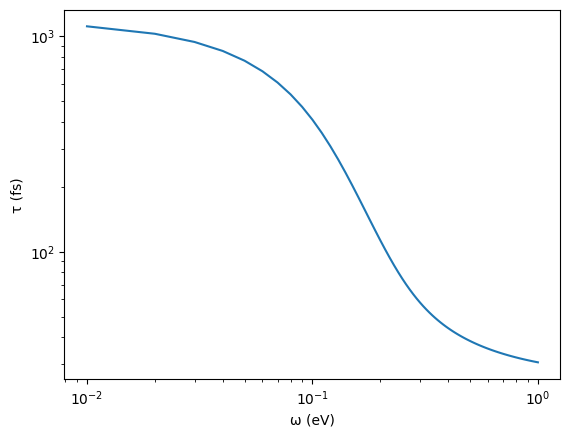

(PyObject[PyObject <matplotlib.axis.XTick object at 0x7fbf84fbb9a0>, PyObject <matplotlib.axis.XTick object at 0x7fbf84fbb370>, PyObject <matplotlib.axis.XTick object at 0x7fbf84fbccd0>], PyObject[PyObject Text(0.01, 0, '$\\mathdefault{10^{-2}}$'), PyObject Text(0.1, 0, '$\\mathdefault{10^{-1}}$'), PyObject Text(1.0, 0, '$\\mathdefault{10^{0}}$')])

In [136]:
loglog(collect(0.01:0.01:1), 1e15 ./ tau)
ylabel("τ (fs)")
xlabel("ω (eV)")
xticks([0.01, 0.1, 1])
#ylim(0, 100)

In [107]:
?loglog

search: loglog Clonglong Culonglong levitov_kramers_kronig_epsilon



Make a plot with log scaling on both the x and y axis.

Call signatures::

    loglog([x], y, [fmt], data=None, **kwargs)
    loglog([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

This is just a thin wrapper around `.plot` which additionally changes
both the x-axis and the y-axis to log scaling. All of the concepts and
parameters of plot can be used here as well.

The additional parameters *base*, *subs* and *nonpositive* control the
x/y-axis properties. They are just forwarded to `.Axes.set_xscale` and
`.Axes.set_yscale`. To use different properties on the x-axis and the
y-axis, use e.g.
``ax.set_xscale("log", base=10); ax.set_yscale("log", base=2)``.

Parameters
----------
base : float, default: 10
    Base of the logarithm.

subs : sequence, optional
    The location of the minor ticks. If *None*, reasonable locations
    are automatically chosen depending on the number of decades in the
    plot. See `.Axes.set_xscale`/`.Axes.set_yscale` for details.

nonpositive : {'mask', 'clip